In [1]:
import pandas as pd


In [3]:
df = pd.read_csv("E:/AIML/PojectUberEats/DataSet/Uber_Eats_data.csv")

In [8]:
df.shape

(23193, 13)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23193 entries, 0 to 23192
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         23193 non-null  str  
 1   online_order                 23193 non-null  str  
 2   book_table                   23193 non-null  str  
 3   rate                         23193 non-null  str  
 4   votes                        23193 non-null  int64
 5   phone                        23193 non-null  str  
 6   location                     23193 non-null  str  
 7   rest_type                    23193 non-null  str  
 8   dish_liked                   23193 non-null  str  
 9   cuisines                     23193 non-null  str  
 10  approx_cost(for two people)  23193 non-null  str  
 11  listed_in(type)              23193 non-null  str  
 12  listed_in(city)              23193 non-null  str  
dtypes: int64(1), str(12)
memory usage: 2.3 MB


In [13]:
df.isna().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
phone                          0
location                       0
rest_type                      0
dish_liked                     0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
listed_in(city)                0
dtype: int64

In [14]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
phone                          0
location                       0
rest_type                      0
dish_liked                     0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
listed_in(city)                0
dtype: int64

In [4]:
df_copy = df.copy()

In [22]:
df_copy['rate'].unique()

<StringArray>
[ '4.1/5',  '3.8/5',  '3.7/5',  '4.6/5',  '4.0/5',  '4.2/5',  '3.9/5',
  '3.0/5',  '3.6/5',  '2.8/5',  '4.4/5',  '3.1/5',  '4.3/5',  '2.6/5',
  '3.3/5',  '3.5/5', '3.8 /5',  '3.2/5',  '4.5/5',  '2.5/5',  '2.9/5',
  '3.4/5',  '2.7/5',  '4.7/5',    'NEW',  '2.4/5',  '2.2/5',  '2.3/5',
  '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5', '4.1 /5', '2.9 /5', '2.7 /5',
 '2.5 /5', '2.6 /5', '4.5 /5', '4.3 /5', '3.7 /5', '4.4 /5',  '4.9/5',
  '2.1/5',  '2.0/5',  '1.8/5', '3.4 /5', '3.6 /5', '3.3 /5', '4.6 /5',
 '4.9 /5', '3.2 /5', '3.0 /5', '2.8 /5', '3.5 /5', '3.1 /5', '4.8 /5',
 '2.3 /5', '4.7 /5', '2.4 /5', '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5']
Length: 63, dtype: str

In [ ]:
condition = df_copy['rate'] == 'NEW'
ratecheck = df[condition]['name'].unique()


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [100]:
df_copy['rate'] = df_copy['rate'].str.replace(" ","").str.split('/').str[0]
df_copy['rate']= pd.to_numeric(df_copy['rate'],errors='coerce')
df_copy['rate'].unique()

array([4.1, 3.8, 3.7, 4.6, 4. , 4.2, 3.9, 3. , 3.6, 2.8, 4.4, 3.1, 4.3,
       2.6, 3.3, 3.5, 3.2, 4.5, 2.5, 2.9, 3.4, 2.7, 4.7, nan, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [ ]:
validrate = df_copy.groupby('name')['cleanrating'].apply(lambda x:x.notna().any())
validrate = validrate[validrate].index


Index(['#L-81 Cafe', '#refuel', '1000 B.C',
       '100ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ°C', '1131 Bar + Kitchen',
       '12th Main - Grand Mercure', '1441 Pizzeria', '1522 - The Pub',
       '154 Breakfast Club', '1722 Urban Bistro',
       ...
       'Zodiac', 'Zodiac - Fortune Select JP Cosmos Hotel', 'Zoey's', 'Zyara',
       'alt',
       'b CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© - Shangri-La Hotel',
       'eat.fit', 'i-Bar - The Park Bangalore', 'nu.tree',
       're:cess - Hilton Bangalore Embassy GolfLinks'],
      dtype='str', name='name', length=3142)

In [79]:
hotelfilter = df_copy[df_copy['rate'].isna()]['name'].unique()

In [80]:
hotelfilter

<StringArray>
[                    'Le Arabia',                  'Brahma Brews',
  'Levitate Brewery and Kitchen',                       'Nourich',
                 'Fusion Theory',                 'Thyme & Whisk',
                      'Foodbell',                  'Biryani Trip',
            'The Flying Trapeze',                    'Ulavacharu',
    'Blue Tokai Coffee Roasters',                    'Biergarten',
                     'Bob's Bar',                 'Baba Chatkora',
             'Empire Restaurant',          '46 Ounces Brewgarden',
 'Shandys-The Beer Cocktail Hub',              'The Twisted Desi',
              'The Buffet Table',                 'Frozen Bottle',
                      'Hammered',                 'Indigo X II P',
                     'Brik Oven',                         'Taiki',
    'Sanchez Taqueria & Cantina',      'Nevermind - Bar & Social',
        'Kapoor's Punjabi Rolls',                     'Kaapikada',
                'Seven Ate Nine',       'Cheers 

In [59]:
groupdata = df_copy.groupby(hotelfilter)['rate'].apply(list)

In [85]:
df['rate'].groupby['name']

TypeError: 'method' object is not subscriptable

In [70]:
df_copy1 = df_copy[df_copy['name'].isin(hotelfilter)]

In [ ]:
df_copy1 = df_copy1.sort_values(by='name')

KeyError: <StringArray>
[                    'Le Arabia',                  'Brahma Brews',
  'Levitate Brewery and Kitchen',                       'Nourich',
                 'Fusion Theory',                 'Thyme & Whisk',
                      'Foodbell',                  'Biryani Trip',
            'The Flying Trapeze',                    'Ulavacharu',
    'Blue Tokai Coffee Roasters',                    'Biergarten',
                     'Bob's Bar',                 'Baba Chatkora',
             'Empire Restaurant',          '46 Ounces Brewgarden',
 'Shandys-The Beer Cocktail Hub',              'The Twisted Desi',
              'The Buffet Table',                 'Frozen Bottle',
                      'Hammered',                 'Indigo X II P',
                     'Brik Oven',                         'Taiki',
    'Sanchez Taqueria & Cantina',      'Nevermind - Bar & Social',
        'Kapoor's Punjabi Rolls',                     'Kaapikada',
                'Seven Ate Nine',     

In [82]:
groupdata = df_copy1.groupby(hotelfilter)['rate'].apply(list)

In [91]:
df_copy.groupby('name')['rate'].mean()


name
#L-81 Cafe                                                                                  3.900000
#refuel                                                                                     3.700000
1000 B.C                                                                                    3.200000
100ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ°C                                                        3.700000
1131 Bar + Kitchen                                                                          4.500000
                                                                                              ...   
b CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© - Shangri-La Hotel    4.300000
eat.fit                                                                                     4.100000
i-Bar - The Park Bangalore                                                                  3.800000
nu.tree                                                                               

In [112]:
df_copy.votes

0        775
1        787
2        918
3         88
4        166
        ... 
23188    128
23189     77
23190    161
23191     81
23192    236
Name: votes, Length: 23193, dtype: int64

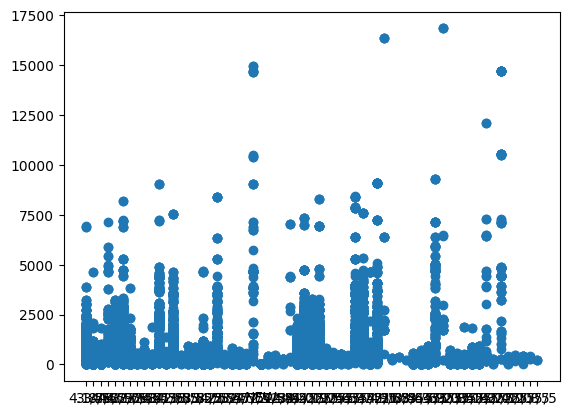

In [5]:
#import seaborn as sns
import matplotlib.pyplot as plt

plt.scatter(df['rate'],df['votes'])
plt.show()

In [8]:
import numpy as np
df_copy['votes_log']  = np.log1p(df_copy['votes'])

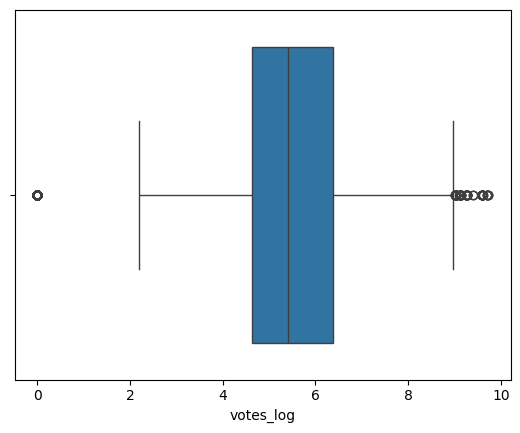

In [9]:
import seaborn as sns

sns.boxplot(x=df_copy['votes_log'])
plt.show()


In [3]:
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [102]:
df_copy['rate'] = df_copy['rate'].fillna(df_copy.groupby(['name','location'])['rate'].transform('mean'))

In [108]:
df_copy['rate'] = df_copy['rate'].round(1)

In [106]:
df_copy['rate']= df_copy['rate'].fillna(df_copy['rate'].mean())

In [110]:
df_copy['rate'] = df_copy['rate'].map("{:.1f}".format)

In [111]:
df_copy['rate'].unique()

<StringArray>
['4.1', '3.8', '3.7', '4.6', '4.0', '4.2', '3.9', '3.0', '3.6', '2.8', '4.4',
 '3.1', '4.3', '2.6', '3.3', '3.5', '3.2', '4.5', '2.5', '2.9', '3.4', '2.7',
 '4.7', '2.4', '2.2', '2.3', '4.8', '4.9', '2.1', '2.0', '1.8']
Length: 31, dtype: str

In [ ]:
#Rating column cleaning

df_copy['rate'] = df_copy['rate'].str.replace(" ","").str.split('/').str[0]
df_copy['rate']= pd.to_numeric(df_copy['rate'],errors='coerce')
df_copy['rate'] = df_copy['rate'].fillna(df_copy.groupby(['name','location'])['rate'].transform('mean'))
df_copy['rate']= df_copy['rate'].fillna(df_copy['rate'].mean())
df_copy['rate'] = df_copy['rate'].round(1)
df_copy['rate'] = df_copy['rate'].map("{:.1f}".format)